#Experimento de la doble rendija

Realizado por: Nicolas Esteban Delgado y Sara Sofia Gonzalez

##Instrucciones
El experimento de la doble rendija encierra muchos de los misterios del mundo cuántico.

En grupos de máximo tres personas debe reproducir de la mejor manera posible el experimento de la doble rendija (usando un laser, cartón paja y papel aluminio, entre otros). Describa el experimento y explique con una simulación simple usando su librería. Agregue esta descripción a la documentación de la librería.

Se calificará la construcción de su experimento, la calidad de su patrón de interferencia, y la descripción que haga del mismo.

Tomen fotos del experimento, fotos del patrón de interferencia y videos de su experimento.

##Descripcion
Un proyecto integral para simular, construir y analizar el famoso experimento de la doble rendija, una de las demostraciones más importantes de la dualidad onda-partícula en la mecánica cuántica. Este proyecto combina física teórica, simulación computacional y trabajo experimental práctico.

Este proyecto proporciona todo lo que se necesita para comprender, simular y construir físicamente el experimento de la doble rendija. Este conjunto de herramientas te guiará a lo largo de todo el proceso.

**Prerrequisitos**

**Para la simulación (requerido):**
* Python 3.8 o superior
* Comprensión básica de física (ondas, interferencia)
* Computador con capacidad gráfica

**Para el experimento físico (requerido):**
* Puntero láser (rojo, 650 nm recomendado)
* Cartón y papel de aluminio
* Cuchilla o bisturí para cortar rendijas precisas
* Habitación o espacio oscuro
* Pantalla blanca o pared
* Regla y herramientas de medición
* Cámara para documentación


#1. Importar librerias

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from simulacion_doble_rendija import (
    DoubleslitSimulator,
    InterferenceAnalyzer,
    plot_interference_pattern
)

# Set up matplotlib for inline plots
%matplotlib inline

print("✅ All libraries imported successfully!")
print("📊 Ready to explore the double-slit experiment!")

✅ All libraries imported successfully!
📊 Ready to explore the double-slit experiment!


#2. Teoría Básica

El experimento de la doble rendija demuestra la interferencia de ondas. Cuando la luz coherente pasa a través de dos rendijas paralelas, se crea un patrón de interferencia en una pantalla. El patrón consiste en:

* **Franjas brillantes:** donde las ondas de ambas rendijas llegan en fase (interferencia constructiva)
* **Franjas oscuras:** donde las ondas llegan fuera de fase (interferencia destructiva)

Las ecuaciones clave son:

* **Separación entre franjas:** Δy = λD / d
* **Franjas brillantes:** d·sen(θ) = mλ (donde m = 0, ±1, ±2, …)
* **Franjas oscuras:** d·sen(θ) = (m + 1/2)λ

Donde:

* λ = longitud de onda de la luz
* D = distancia a la pantalla
* d = separación entre rendijas
* θ = ángulo desde el centro


In [ ]:
# Interactive widget for exploring parameter effects
def interactive_double_slit():
    # Create widgets
    wavelength_slider = widgets.FloatSlider(
        value=650,
        min=400,
        max=800,
        step=10,
        description='Wavelength (nm):',
        style={'description_width': 'initial'}
    )

    slit_width_slider = widgets.FloatSlider(
        value=50,
        min=10,
        max=200,
        step=5,
        description='Slit Width (μm):',
        style={'description_width': 'initial'}
    )

    slit_separation_slider = widgets.FloatSlider(
        value=200,
        min=50,
        max=500,
        step=10,
        description='Slit Separation (μm):',
        style={'description_width': 'initial'}
    )

    screen_distance_slider = widgets.FloatSlider(
        value=1.0,
        min=0.5,
        max=3.0,
        step=0.1,
        description='Screen Distance (m):',
        style={'description_width': 'initial'}
    )

    double_slit_checkbox = widgets.Checkbox(
        value=True,
        description='Double Slit (uncheck for single slit)',
        style={'description_width': 'initial'}
    )

    output = widgets.Output()

    def update_plot(wavelength, slit_width, slit_separation, screen_distance, double_slit):
        with output:
            output.clear_output(wait=True)

            # Create simulator with current parameters
            simulator = DoubleslitSimulator(
                wavelength=wavelength * 1e-9,  # Convert nm to m
                slit_width=slit_width * 1e-6,  # Convert μm to m
                slit_separation=slit_separation * 1e-6,  # Convert μm to m
                screen_distance=screen_distance
            )

            # Run simulation
            y_positions, intensity = simulator.simulate_experiment(
                screen_width=0.01,  # 1 cm
                resolution=1000,
                double_slit=double_slit
            )

            # Plot
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

            # 1D intensity plot
            y_mm = y_positions * 1000
            ax1.plot(y_mm, intensity, 'b-', linewidth=2)
            ax1.set_xlabel('Position on Screen (mm)')
            ax1.set_ylabel('Normalized Intensity')
            title = 'Double-Slit' if double_slit else 'Single-Slit'
            ax1.set_title(f'{title} Interference Pattern')
            ax1.grid(True, alpha=0.3)

            # 2D visualization
            pattern_2d = np.tile(intensity, (50, 1))
            extent = [y_mm[0], y_mm[-1], -1, 1]
            im = ax2.imshow(pattern_2d, extent=extent, aspect='auto', cmap='hot')
            ax2.set_xlabel('Position on Screen (mm)')
            ax2.set_ylabel('Height (arbitrary)')
            ax2.set_title('2D Pattern Visualization')
            plt.colorbar(im, ax=ax2, label='Intensity')

            plt.tight_layout()
            plt.show()

            # Calculate and display fringe spacing
            if double_slit:
                theoretical_spacing = (wavelength * 1e-9 * screen_distance /
                                     (slit_separation * 1e-6)) * 1000
                print(f"Theoretical fringe spacing: {theoretical_spacing:.2f} mm")

    # Create interactive widget
    interactive_widget = widgets.interactive(
        update_plot,
        wavelength=wavelength_slider,
        slit_width=slit_width_slider,
        slit_separation=slit_separation_slider,
        screen_distance=screen_distance_slider,
        double_slit=double_slit_checkbox
    )

    display(interactive_widget, output)

# Run the interactive widget
interactive_double_slit()

interactive(children=(FloatSlider(value=650.0, description='Wavelength (nm):', max=800.0, min=400.0, step=10.0…

Output()

#3. Comparación: Rendija Simple vs Doble Rendija

Comparemos los patrones de una rendija simple y una doble rendija para entender la diferencia entre difracción e interferencia.

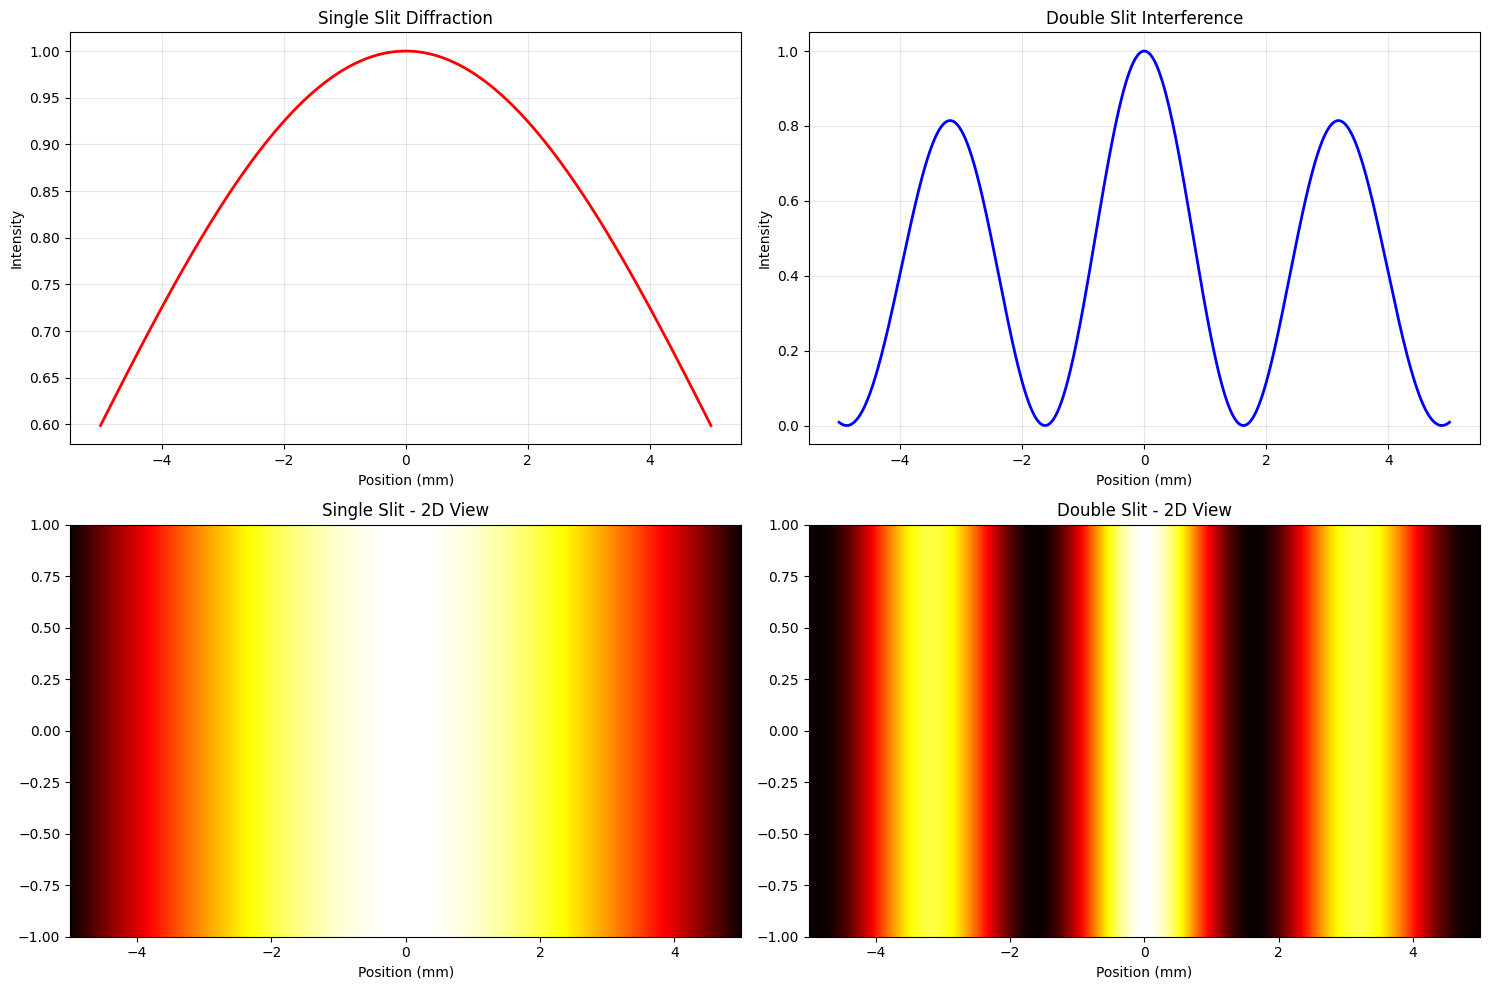

Key Differences:
• Single slit: Broad central maximum with weaker side maxima (diffraction)
• Double slit: Multiple sharp fringes of similar intensity (interference)
• Double slit pattern is modulated by single slit envelope


In [ ]:
# Compare single and double slit patterns
simulator = DoubleslitSimulator()

# Generate both patterns
y_pos, single_intensity = simulator.simulate_experiment(double_slit=False)
y_pos, double_intensity = simulator.simulate_experiment(double_slit=True)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Single slit - 1D
y_mm = y_pos * 1000
axes[0, 0].plot(y_mm, single_intensity, 'r-', linewidth=2)
axes[0, 0].set_xlabel('Position (mm)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].set_title('Single Slit Diffraction')
axes[0, 0].grid(True, alpha=0.3)

# Double slit - 1D
axes[0, 1].plot(y_mm, double_intensity, 'b-', linewidth=2)
axes[0, 1].set_xlabel('Position (mm)')
axes[0, 1].set_ylabel('Intensity')
axes[0, 1].set_title('Double Slit Interference')
axes[0, 1].grid(True, alpha=0.3)

# Single slit - 2D
single_2d = np.tile(single_intensity, (50, 1))
extent = [y_mm[0], y_mm[-1], -1, 1]
axes[1, 0].imshow(single_2d, extent=extent, aspect='auto', cmap='hot')
axes[1, 0].set_xlabel('Position (mm)')
axes[1, 0].set_title('Single Slit - 2D View')

# Double slit - 2D
double_2d = np.tile(double_intensity, (50, 1))
im = axes[1, 1].imshow(double_2d, extent=extent, aspect='auto', cmap='hot')
axes[1, 1].set_xlabel('Position (mm)')
axes[1, 1].set_title('Double Slit - 2D View')

plt.tight_layout()
plt.show()

print("Key Differences:")
print("• Single slit: Broad central maximum with weaker side maxima (diffraction)")
print("• Double slit: Multiple sharp fringes of similar intensity (interference)")
print("• Double slit pattern is modulated by single slit envelope")

#4. Efectos de la Longitud de Onda

Diferentes longitudes de onda (colores) de la luz crean distintos patrones de interferencia. Por eso, cuando se usa luz blanca, se observan franjas de colores tipo arcoíris.

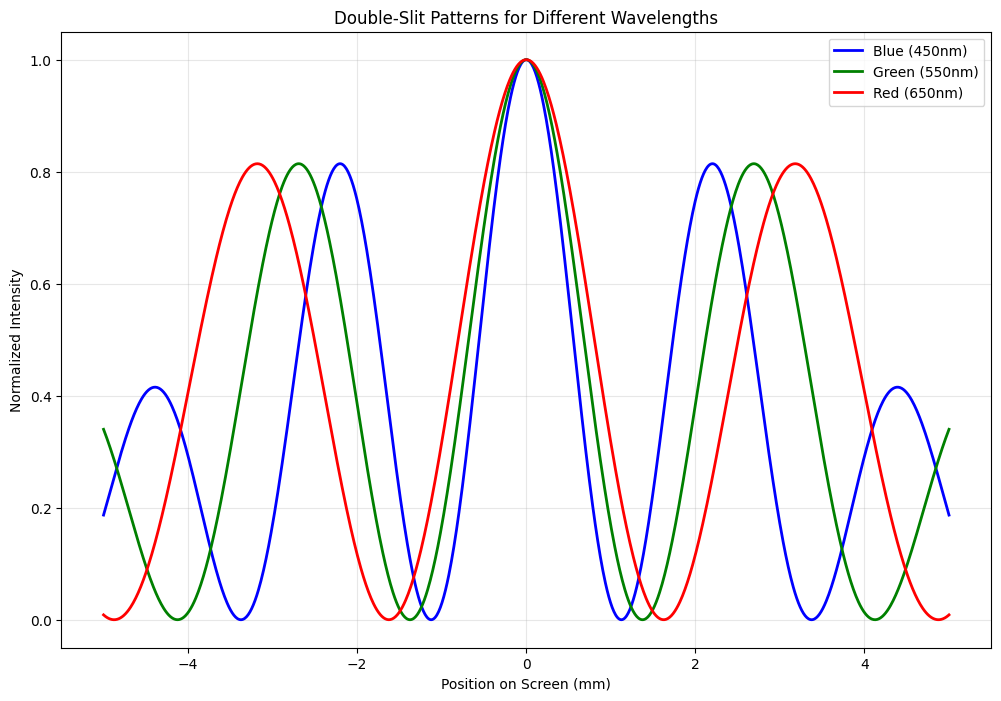

Observations:
• Longer wavelengths (red) → wider fringe spacing
• Shorter wavelengths (blue) → narrower fringe spacing
• This is why laser pointers work better than white light for clear patterns


In [ ]:
# Demonstrate wavelength effects
wavelengths = [450e-9, 550e-9, 650e-9]  # Blue, Green, Red
colors = ['blue', 'green', 'red']
labels = ['Blue (450nm)', 'Green (550nm)', 'Red (650nm)']

plt.figure(figsize=(12, 8))

for wavelength, color, label in zip(wavelengths, colors, labels):
    simulator = DoubleslitSimulator(wavelength=wavelength)
    y_pos, intensity = simulator.simulate_experiment()

    plt.plot(y_pos * 1000, intensity, color=color, linewidth=2, label=label)

plt.xlabel('Position on Screen (mm)')
plt.ylabel('Normalized Intensity')
plt.title('Double-Slit Patterns for Different Wavelengths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Observations:")
print("• Longer wavelengths (red) → wider fringe spacing")
print("• Shorter wavelengths (blue) → narrower fringe spacing")
print("• This is why laser pointers work better than white light for clear patterns")

#5. Análisis de Datos Experimentales

Esta sección muestra cómo analizar los datos obtenidos en tu experimento físico de la doble rendija.

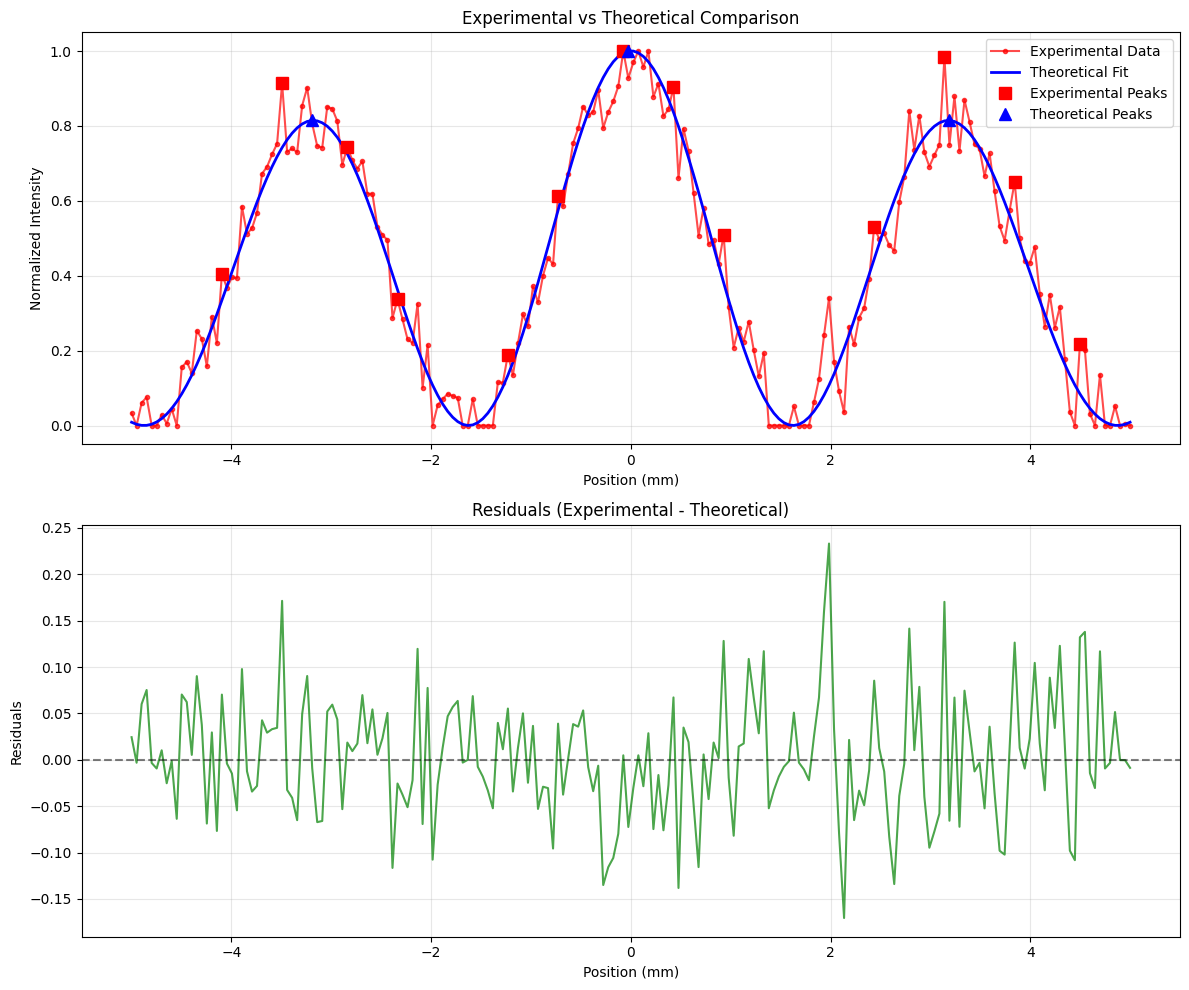

ANALYSIS RESULTS:
Correlation coefficient: 0.979
RMS error: 0.065
Number of peaks found:
  Experimental: 13
  Theoretical: 3
✓ Excellent agreement with theory!


In [ ]:
# Example of experimental data analysis
def analyze_experimental_data():
    # Create synthetic experimental data with realistic noise
    simulator = DoubleslitSimulator()
    y_pos, theoretical = simulator.simulate_experiment(resolution=200)

    # Add noise to simulate experimental data
    rng = np.random.default_rng(42)
    noise = rng.normal(0, 0.08, len(theoretical))
    experimental = theoretical + noise
    experimental = np.clip(experimental, 0, 1)

    # Analyze with InterferenceAnalyzer
    analyzer = InterferenceAnalyzer()
    analyzer.experimental_data = experimental

    # Compare with theory
    comparison = analyzer.compare_with_theory(simulator)

    # Plot results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Main comparison
    y_mm = y_pos * 1000
    ax1.plot(y_mm, experimental, 'ro-', alpha=0.7, markersize=3, label='Experimental Data')
    ax1.plot(y_mm, analyzer.theoretical_data, 'b-', linewidth=2, label='Theoretical Fit')

    # Mark peaks
    if comparison['experimental_peaks']:
        exp_peak_pos = y_mm[comparison['experimental_peaks']]
        exp_peak_int = experimental[comparison['experimental_peaks']]
        ax1.plot(exp_peak_pos, exp_peak_int, 'rs', markersize=8, label='Experimental Peaks')

    if comparison['theoretical_peaks']:
        theo_peak_pos = y_mm[comparison['theoretical_peaks']]
        theo_peak_int = analyzer.theoretical_data[comparison['theoretical_peaks']]
        ax1.plot(theo_peak_pos, theo_peak_int, 'b^', markersize=8, label='Theoretical Peaks')

    ax1.set_xlabel('Position (mm)')
    ax1.set_ylabel('Normalized Intensity')
    ax1.set_title('Experimental vs Theoretical Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Residuals
    residuals = experimental - analyzer.theoretical_data
    ax2.plot(y_mm, residuals, 'g-', alpha=0.7)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Position (mm)')
    ax2.set_ylabel('Residuals')
    ax2.set_title('Residuals (Experimental - Theoretical)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print analysis results
    print("ANALYSIS RESULTS:")
    print(f"Correlation coefficient: {comparison['correlation']:.3f}")
    print(f"RMS error: {comparison['rms_error']:.3f}")
    print(f"Number of peaks found:")
    print(f"  Experimental: {len(comparison['experimental_peaks'])}")
    print(f"  Theoretical: {len(comparison['theoretical_peaks'])}")

    if comparison['correlation'] > 0.9:
        print("✓ Excellent agreement with theory!")
    elif comparison['correlation'] > 0.7:
        print("✓ Good agreement with theory")
    else:
        print("⚠ Poor agreement - check experimental setup")

analyze_experimental_data()

#6. Guía del Experimento Físico - Materiales y Construcción
¡Ahora construyamos el experimento real de la doble rendija! Esta sección muestra los materiales necesarios y el proceso de construcción paso a paso.

**Materiales requeridos:**

Componentes esenciales:
- Puntero láser (rojo, se recomienda una longitud de onda de 650 nm)
- Cartón (para la estructura de montaje)
- Papel de aluminio (para crear las rendijas)
- Cuchilla o bisturí de precisión (para cortar las rendijas)
- Regla (para las mediciones)
- Pantalla blanca o papel (como superficie de proyección)
- Cámara (un celular es suficiente para la documentación)

Opcionales pero útiles:
- Cinta negra (para bloquear fugas de luz)
- Habitación oscura o caja (para reducir la luz ambiental)
- Pinzas o cinta (para asegurar los componentes)
- Cuaderno (para registrar mediciones)

MATERIALES Y GUIA DE CONSTRUCCION


 1: :
------------------------------------------------------------


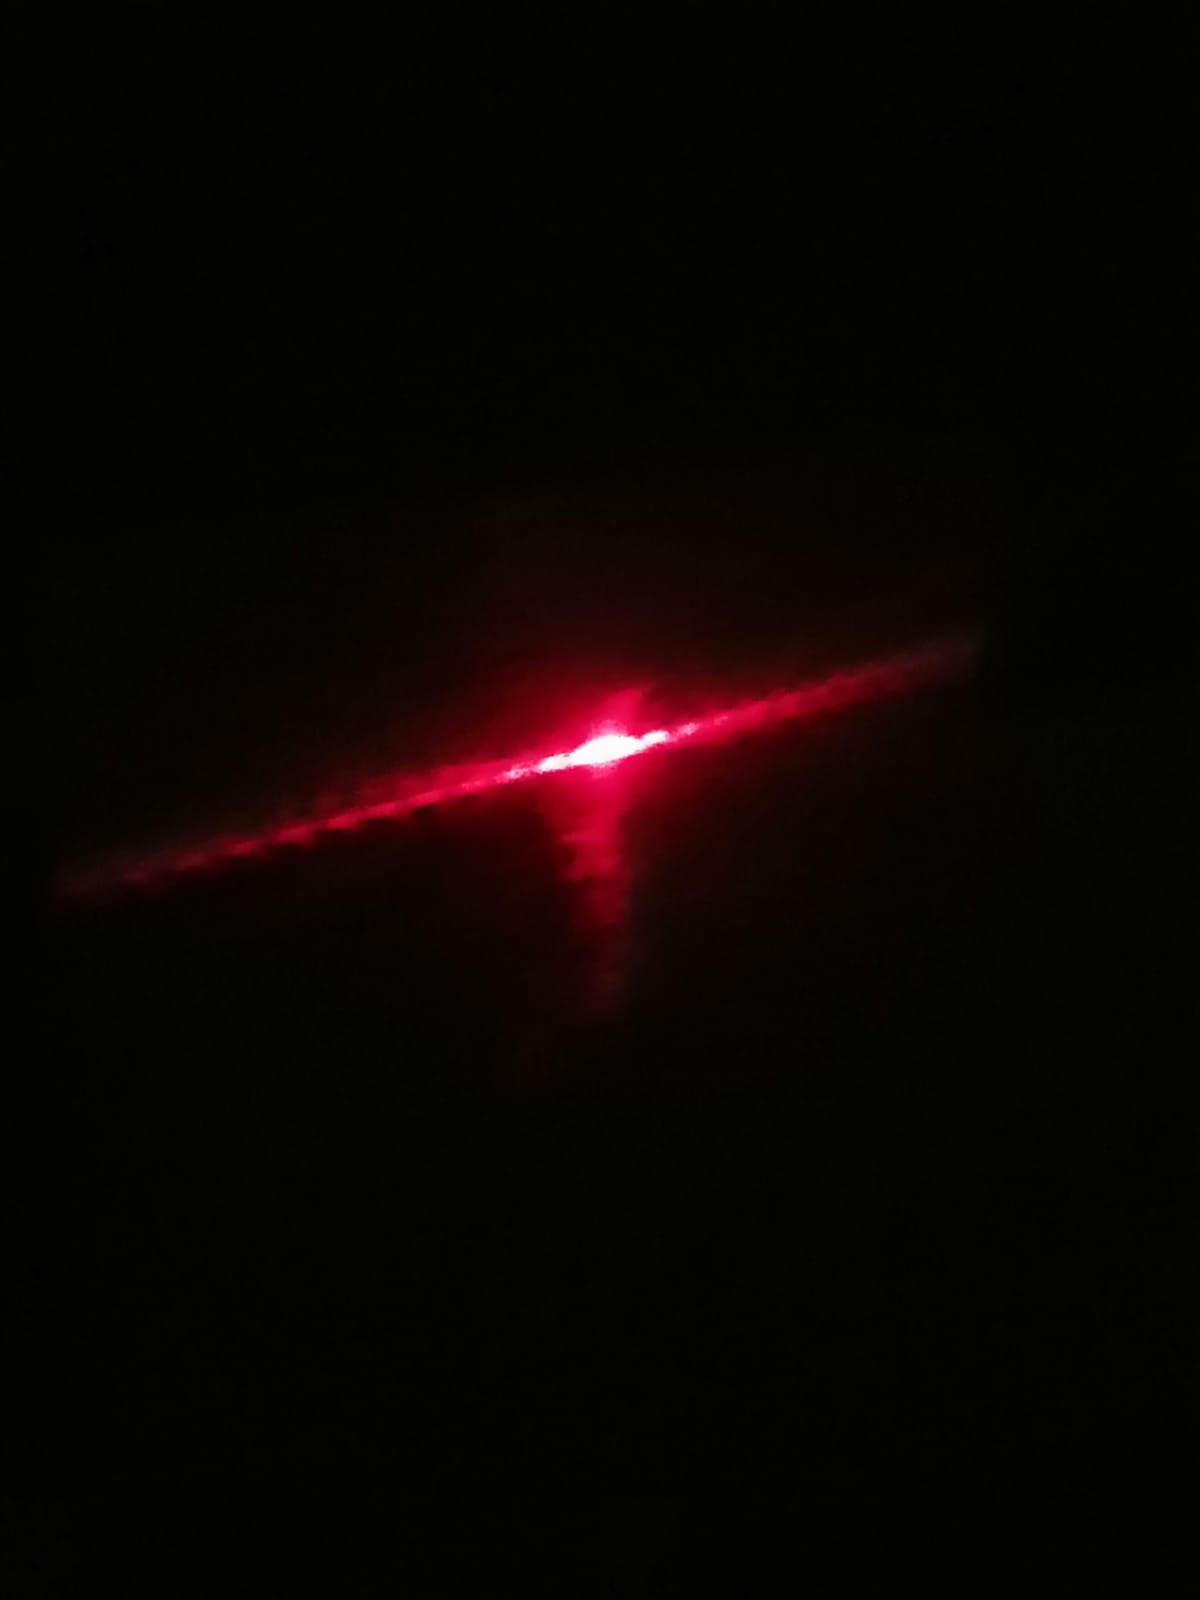


 2: :
------------------------------------------------------------


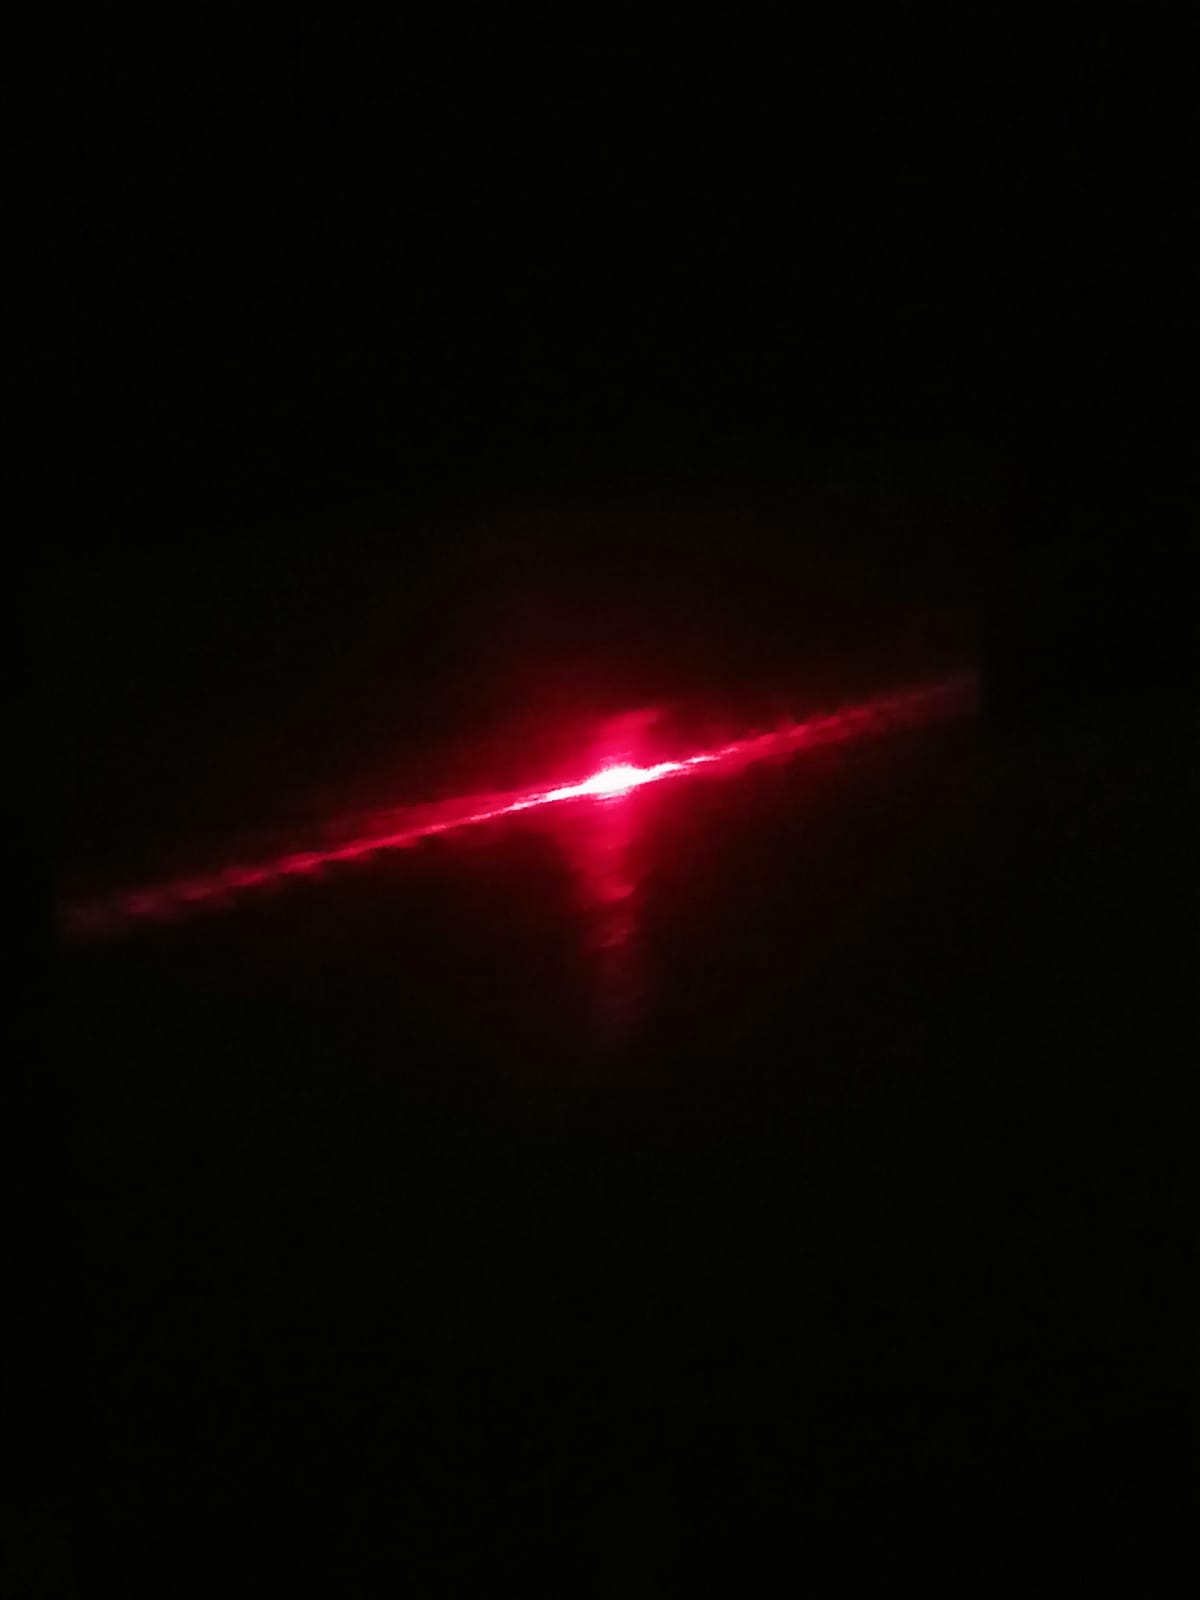


 Construccion Final:
------------------------------------------------------------


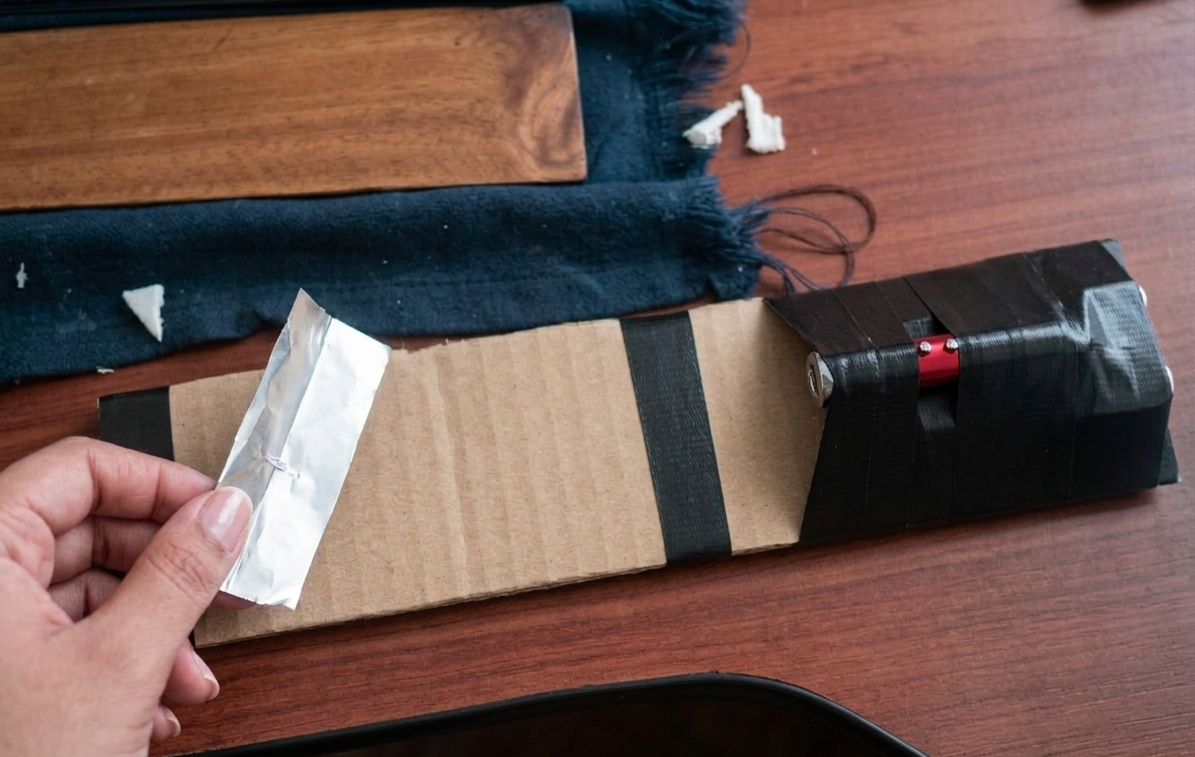


PASOS DE CONSTRUCCION:

**1. CONSTRUIR LA ESTRUCTURA (Imágenes 1 y 2):**

* Corta piezas de cartón para crear una estructura de soporte estable
* El “marco” sostiene el papel de aluminio con las rendijas
* Asegúrate de que la estructura sea rígida y no se tambalee
* Deja espacio para que el láser pueda pasar

---

**2. CREAR LA DOBLE RENDIJA:**

* Toma un trozo de papel de aluminio (aprox. 5 cm x 5 cm)
* Con una cuchilla afilada, corta cuidadosamente DOS rendijas paralelas
* Cada rendija debe ser muy delgada (~0.05 mm) y recta
* Las rendijas deben estar separadas unos 0.2 mm (¡usa una regla!)
* Consejo: haz los cortes en un solo movimiento suave para bordes limpios

---

**3. ENSAMBLAR EL DISPOSITIVO (Imagen 3):**

* Coloca el papel de aluminio en el marco de cartón
* Asegúrate de que esté plano y que las rendijas estén verticales
* Posiciona el puntero láser para que atraviese ambas rendijas
* Coloca una pantalla o pared blanca a 1–2 metros de distancia

---

**4. ALINEACIÓN:**

* En

In [ ]:
# Display the materials and construction process
from IPython.display import Image, display
import os

print("=" * 60)
print("MATERIALES Y GUIA DE CONSTRUCCION")
print("=" * 60)
print()

# Check if images exist
assets_path = "assets"
images = {
    "1: ": os.path.join(assets_path, "/content/partea.jpg"),
    "2: ": os.path.join(assets_path, "/content/parteb.jpg"),
    "Construccion final": os.path.join(assets_path, "/content/ConstruccionFinal.png")
}

# Display images if they exist
for name, path in images.items():
    if os.path.exists(path):
        print(f"\n {name.replace('_', ' ').title()}:")
        print("-" * 60)
        display(Image(filename=path, width=600))
    else:
        print(f"\n⚠️ Image not found: {path}")

print("\n" + "=" * 60)
print("PASOS DE CONSTRUCCION:")
print("=" * 60)
print("""
**1. CONSTRUIR LA ESTRUCTURA (Imágenes 1 y 2):**

* Corta piezas de cartón para crear una estructura de soporte estable
* El “marco” sostiene el papel de aluminio con las rendijas
* Asegúrate de que la estructura sea rígida y no se tambalee
* Deja espacio para que el láser pueda pasar

---

**2. CREAR LA DOBLE RENDIJA:**

* Toma un trozo de papel de aluminio (aprox. 5 cm x 5 cm)
* Con una cuchilla afilada, corta cuidadosamente DOS rendijas paralelas
* Cada rendija debe ser muy delgada (~0.05 mm) y recta
* Las rendijas deben estar separadas unos 0.2 mm (¡usa una regla!)
* Consejo: haz los cortes en un solo movimiento suave para bordes limpios

---

**3. ENSAMBLAR EL DISPOSITIVO (Imagen 3):**

* Coloca el papel de aluminio en el marco de cartón
* Asegúrate de que esté plano y que las rendijas estén verticales
* Posiciona el puntero láser para que atraviese ambas rendijas
* Coloca una pantalla o pared blanca a 1–2 metros de distancia

---

**4. ALINEACIÓN:**

* Enciende el láser en una habitación oscura
* Ajusta hasta que el haz pase por las rendijas
* Busca el patrón de interferencia en la pantalla
* Ajusta finamente hasta obtener el patrón más claro

---

**5. DOCUMENTACIÓN:**

* Toma fotos del montaje (usa las imágenes 1–3 como referencia)
* Fotografía claramente el patrón de interferencia
* Mide y registra todas las distancias
* Graba un video mostrando todo el experimento

---

* ❗ NUNCA mires directamente al haz del láser

""")

#7. Calculadora de Parámetros para tu Experimento

Usa esta calculadora para predecir lo que deberías observar en tu experimento físico.

In [ ]:
# Interactive calculator for experimental parameters
# Import necessary libraries for this cell
import numpy as np
import ipywidgets as widgets
from IPython.display import display

def experimental_calculator():
    print("EXPERIMENTAL PARAMETER CALCULATOR")
    print("=" * 40)

    # Get input parameters
    wavelength_nm = widgets.FloatText(
        value=650,
        description='Laser wavelength (nm):',
        style={'description_width': 'initial'}
    )

    slit_separation_um = widgets.FloatText(
        value=200,
        description='Slit separation (μm):',
        style={'description_width': 'initial'}
    )

    screen_distance_m = widgets.FloatText(
        value=1.0,
        description='Screen distance (m):',
        style={'description_width': 'initial'}
    )

    calculate_button = widgets.Button(
        description='Calculate',
        button_style='success'
    )

    output = widgets.Output()

    def on_calculate_clicked(b):
        with output:
            output.clear_output()

            # Get values
            wavelength = wavelength_nm.value * 1e-9  # Convert to meters
            slit_sep = slit_separation_um.value * 1e-6  # Convert to meters
            distance = screen_distance_m.value

            # Calculate fringe spacing
            fringe_spacing_m = wavelength * distance / slit_sep
            fringe_spacing_mm = fringe_spacing_m * 1000

            # Calculate angular spacing
            angular_spacing_rad = wavelength / slit_sep
            angular_spacing_deg = angular_spacing_rad * 180 / np.pi

            # Estimate number of visible fringes (in 1cm screen width)
            screen_width = 0.01  # 1 cm
            num_fringes = int(screen_width / (2 * fringe_spacing_m))

            print("PREDICTED RESULTS:")
            print("-" * 20)
            print(f"Fringe spacing: {fringe_spacing_mm:.2f} mm")
            print(f"Angular fringe spacing: {angular_spacing_deg:.3f}°")
            print(f"Number of fringes in 1cm: ~{num_fringes*2} total")
            print()
            print("MEASUREMENT TIPS:")
            print(f"• Look for bright spots every {fringe_spacing_mm:.2f} mm")
            print(f"• Central bright fringe should be brightest")
            print(f"• Pattern should be symmetric")

            if fringe_spacing_mm < 0.5:
                print("⚠ Fringes may be too close together - increase screen distance")
            elif fringe_spacing_mm > 5:
                print("⚠ Fringes may be too far apart - decrease screen distance")
            else:
                print("✓ Good fringe spacing for observation")

    calculate_button.on_click(on_calculate_clicked)

    display(wavelength_nm, slit_separation_um, screen_distance_m,
            calculate_button, output)

experimental_calculator()

EXPERIMENTAL PARAMETER CALCULATOR


FloatText(value=650.0, description='Laser wavelength (nm):', style=DescriptionStyle(description_width='initial…

FloatText(value=200.0, description='Slit separation (μm):', style=DescriptionStyle(description_width='initial'…

FloatText(value=1.0, description='Screen distance (m):', style=DescriptionStyle(description_width='initial'))

Button(button_style='success', description='Calculate', style=ButtonStyle())

Output()

##Problemas Comunes

¿Tienes problemas para ver el patrón de interferencia? Aquí tienes soluciones a los problemas más frecuentes:

**Problema 1: No se ve ningún patrón**

Posibles causas:

- El láser no está alineado con las rendijas
- La habitación está demasiado iluminada
- Las rendijas están demasiado separadas o demasiado juntas
- La pantalla está muy cerca o muy lejos

Soluciones:

- Alinea cuidadosamente el láser para que pase por ambas rendijas
- Trabaja en una habitación completamente oscura
- Prueba diferentes separaciones entre rendijas (0.1 – 0.5 mm)
- Ajusta la distancia de la pantalla (intenta entre 1 y 2 metros)

**Problema 2: El patrón es muy borroso o tenue**

Posibles causas:
- Las rendijas son demasiado anchas
- Las rendijas no están rectas o no son paralelas
- El papel de aluminio no está plano
- El montaje vibra o se mueve

Soluciones:
- Haz rendijas más delgadas con una cuchilla nueva
- Vuelve a hacer las rendijas asegurándote de que sean paralelas
- Estira bien el papel de aluminio en el soporte
- Estabiliza todos los componentes y evita tocarlos durante la observación

**Problema 3: El patrón se ve, pero no coincide con la teoría**

Posibles causas:

- Las mediciones son inexactas
- La separación entre rendijas está mal medida
- Se está usando una longitud de onda incorrecta

Soluciones:

- Vuelve a medir todas las distancias con cuidado
- Mide la separación de las rendijas con aumento si es posible
- Verifica la longitud de onda del láser (usualmente 650 nm para rojo, 532 nm para verde)

**Consejos para pruebas:**

- Prueba con una sola rendija: bloquea una rendija; deberías ver un patrón de difracción simple
- Verifica reversibilidad: bloquea rendijas alternadas; el patrón debe mantenerse similar
- Comprueba simetría: el patrón debe ser perfectamente simétrico respecto al centro
- Prueba de distancia: mueve la pantalla más cerca o más lejos; el espaciamiento de las franjas debe cambiar proporcionalmente

#8. Herramienta Interactiva de Análisis de Datos

Utiliza esta herramienta interactiva para analizar tus mediciones experimentales reales y compararlas con las predicciones teóricas:

In [ ]:
# Interactive tool for analyzing your experimental data
# Import necessary libraries for this cell
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def analyze_my_measurements():
    """
    Interactive widget for comparing experimental and theoretical results
    """
    # Create input widgets
    print("🔬 EXPERIMENTAL DATA ANALYZER")
    print("=" * 60)
    print("Enter your measured values:")
    print()

    # Experimental parameters
    wavelength_input = widgets.FloatText(
        value=650,
        description='Laser wavelength (nm):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    slit_sep_input = widgets.FloatText(
        value=0.2,
        description='Slit separation (mm):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    screen_dist_input = widgets.FloatText(
        value=1.5,
        description='Screen distance (m):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    # Measured fringe spacings
    print("Enter your 5 fringe spacing measurements:")
    fringe_inputs = [
        widgets.FloatText(
            value=0.0,
            description=f'Measurement {i+1} (mm):',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='400px')
        )
        for i in range(5)
    ]

    analyze_button = widgets.Button(
        description='Analyze Results',
        button_style='success',
        layout=widgets.Layout(width='200px')
    )

    output = widgets.Output()

    def on_analyze(b):
        with output:
            output.clear_output()

            # Get values
            wavelength = wavelength_input.value * 1e-9  # nm to m
            slit_sep = slit_sep_input.value * 1e-3  # mm to m
            screen_dist = screen_dist_input.value  # already in m

            # Get fringe measurements
            measurements = [f.value for f in fringe_inputs if f.value > 0]

            if not measurements:
                print("❌ Please enter at least one fringe spacing measurement!")
                return

            # Calculate average experimental fringe spacing
            avg_experimental = np.mean(measurements)
            std_experimental = np.std(measurements) if len(measurements) > 1 else 0

            # Calculate theoretical fringe spacing
            theoretical = (wavelength * screen_dist / slit_sep) * 1000  # Convert to mm

            # Calculate percent error
            percent_error = abs(avg_experimental - theoretical) / theoretical * 100

            # Display results
            print("╔" + "═" * 58 + "╗")
            print("║" + " " * 20 + "ANALYSIS RESULTS" + " " * 22 + "║")
            print("╚" + "═" * 58 + "╝")
            print()

            print("📊 YOUR MEASUREMENTS:")
            print("─" * 60)
            for i, m in enumerate(measurements, 1):
                print(f"   Measurement {i}: {m:.3f} mm")
            print(f"   Average: {avg_experimental:.3f} mm")
            if len(measurements) > 1:
                print(f"   Standard deviation: {std_experimental:.3f} mm")
            print()

            print("🎯 THEORETICAL PREDICTION:")
            print("─" * 60)
            print(f"   λ = {wavelength*1e9:.1f} nm")
            print(f"   D = {screen_dist:.2f} m")
            print(f"   d = {slit_sep*1e3:.3f} mm")
            print(f"   Δy = λD/d = {theoretical:.3f} mm")
            print()

            print("📈 COMPARISON:")
            print("─" * 60)
            print(f"   Experimental: {avg_experimental:.3f} mm")
            print(f"   Theoretical:  {theoretical:.3f} mm")
            print(f"   Difference:   {abs(avg_experimental - theoretical):.3f} mm")
            print(f"   Percent error: {percent_error:.2f}%")
            print()

            # Quality assessment
            print("✨ ASSESSMENT:")
            print("─" * 60)
            if percent_error < 10:
                print("   🌟 EXCELLENT! Your results match theory very well!")
                print("   Your experimental technique is accurate.")
            elif percent_error < 20:
                print("   ✅ GOOD! Your results are reasonably accurate.")
                print("   Minor improvements could reduce error further.")
            elif percent_error < 30:
                print("   ⚠️  ACCEPTABLE. Results show the right trend.")
                print("   Consider: more careful measurements, better alignment.")
            else:
                print("   ❌ HIGH ERROR. Check your measurements:")
                print("   • Is slit separation measured correctly?")
                print("   • Is screen distance accurate?")
                print("   • Are fringes measured consistently?")

            # Visualization
            print()
            print("📊 VISUAL COMPARISON:")
            print("─" * 60)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

            # Bar chart comparison
            categories = ['Experimental', 'Theoretical']
            values = [avg_experimental, theoretical]
            colors = ['#3498db', '#e74c3c']

            bars = ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
            ax1.set_ylabel('Fringe Spacing (mm)', fontsize=12)
            ax1.set_title('Experimental vs Theoretical', fontsize=14, fontweight='bold')
            ax1.grid(axis='y', alpha=0.3)

            # Add value labels on bars
            for bar, val in zip(bars, values):
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.3f} mm',
                        ha='center', va='bottom', fontsize=11, fontweight='bold')

            # Error bars if multiple measurements
            if len(measurements) > 1:
                ax1.errorbar([0], [avg_experimental], yerr=[std_experimental],
                           fmt='none', ecolor='black', capsize=10, linewidth=2)

            # Scatter plot of measurements
            ax2.scatter(range(1, len(measurements)+1), measurements,
                       s=100, color='#3498db', alpha=0.7, edgecolor='black', linewidth=2)
            ax2.axhline(y=theoretical, color='#e74c3c', linestyle='--',
                       linewidth=2, label=f'Theoretical = {theoretical:.3f} mm')
            ax2.axhline(y=avg_experimental, color='#3498db', linestyle='--',
                       linewidth=2, alpha=0.7, label=f'Average = {avg_experimental:.3f} mm')
            ax2.set_xlabel('Measurement Number', fontsize=12)
            ax2.set_ylabel('Fringe Spacing (mm)', fontsize=12)
            ax2.set_title('Individual Measurements', fontsize=14, fontweight='bold')
            ax2.legend(fontsize=10)
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            print()
            print("╚" + "═" * 58 + "╝")

    analyze_button.on_click(on_analyze)

    # Display all widgets
    display(wavelength_input, slit_sep_input, screen_dist_input)
    for fi in fringe_inputs:
        display(fi)
    display(analyze_button, output)

# Run the analyzer
analyze_my_measurements()

🔬 EXPERIMENTAL DATA ANALYZER
Enter your measured values:

Enter your 5 fringe spacing measurements:


FloatText(value=650.0, description='Laser wavelength (nm):', layout=Layout(width='400px'), style=DescriptionSt…

FloatText(value=0.2, description='Slit separation (mm):', layout=Layout(width='400px'), style=DescriptionStyle…

FloatText(value=1.5, description='Screen distance (m):', layout=Layout(width='400px'), style=DescriptionStyle(…

FloatText(value=0.0, description='Measurement 1 (mm):', layout=Layout(width='400px'), style=DescriptionStyle(d…

...

FloatText(value=0.0, description='Measurement 3 (mm):', layout=Layout(width='400px'), style=DescriptionStyle(d…

FloatText(value=0.0, description='Measurement 4 (mm):', layout=Layout(width='400px'), style=DescriptionStyle(d…

FloatText(value=0.0, description='Measurement 5 (mm):', layout=Layout(width='400px'), style=DescriptionStyle(d…

Button(button_style='success', description='Analyze Results', layout=Layout(width='200px'), style=ButtonStyle(…

Output()